# Ensemble Runner Tutorial — `EnsembleMAP` & `EnsembleVI`

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/ensemble_runner_tutorial.ipynb)

A tour of `pyrox.inference`'s **NumPyro-style runner classes** — `EnsembleMAP` and `EnsembleVI`. Both expose the same three-method `init` / `update` / `run` API as `numpyro.infer.SVI`, but every operation is ensembled by `vmap` over a leading `(E,)` axis. Internally they compose the lower-level primitives (`ensemble_init`, `ensemble_step`) you may have seen in the [primitives tutorial](./ensemble_primitives_tutorial.ipynb).

**What you'll learn:**

1. Why a class wrapper exists when there are perfectly good free functions — and when to reach for it.
2. **`EnsembleMAP`** — three call patterns: the manual `init` + `update` loop (full Python control), the one-shot `run` (`lax.scan`'d for speed), and the bare `ensemble_map` sugar.
3. **`EnsembleVI`** — the same shape on a NumPyro model + `AutoNormal` guide. Each ensemble member is an independent mean-field VI surrogate; the predictive becomes a mixture over both members and within-member posterior samples.
4. The qualitative difference between an ensemble of MAP point-masses and an ensemble of variational distributions, visualized on the same dataset.

## Background — the runner contract and the math behind it

### Why a class?

The free-function primitives (`ensemble_init`, `ensemble_step`) are intentionally minimal: they take everything as keyword arguments, return tuples, and assume nothing about your training loop. That's great for one-off experiments and bridge code, but in production you usually want a single immutable object that bundles the configuration (`log_joint`, `init_fn`, `optimizer`, `ensemble_size`, `prior_weight`) so you don't have to thread those arguments through every call site.

`EnsembleMAP` is that bundle. It is an `equinox.Module`, so it is itself a PyTree — JIT-friendly, picklable, and safe to pass across function boundaries — and it exposes exactly three methods, each mirroring `numpyro.infer.SVI`:

| Method | Mirror in `numpyro.infer.SVI` | Purpose |
|---|---|---|
| `init(seed)` | `svi.init(rng_key, *args)` | initialize stacked params + optimizer state |
| `update(state, x, y)` | `svi.update(state, *args)` | one ensemble step on a batch |
| `run(seed, T, x, y)` | `svi.run(rng_key, num_steps, *args)` | full training loop, `lax.scan`-driven |

### MAP as a fixed-point of the score

Per ensemble member, MAP solves

$$\hat\theta_e \;=\; \arg\min_\theta\Bigl[-\log p(y \mid x, \theta) \;-\; w_{\text{prior}}\log p(\theta)\Bigr],$$

equivalently a fixed-point of the regularized **score function**:

$$\nabla_\theta \log p(y \mid x, \hat\theta_e) \;+\; w_{\text{prior}}\,\nabla_\theta \log p(\hat\theta_e) \;=\; 0.$$

SGD with a small enough learning rate is a discrete-time approximation of gradient flow on this potential, and Adam is the same flow with per-coordinate adaptive preconditioning by exponentially-weighted estimates of the gradient's first and second moments.

### VI as KL minimization

VI replaces the intractable posterior $p(\theta \mid y, x) \propto p(y \mid x, \theta)\,p(\theta)$ with a tractable surrogate $q_{\phi}(\theta)$ from a parametric family (here: mean-field Gaussian, via NumPyro's `AutoNormal`). The variational parameters $\phi$ are chosen to minimize the reverse KL divergence,

$$\phi^* \;=\; \arg\min_\phi\,\mathrm{KL}\!\Bigl(q_\phi(\theta)\,\Big\|\,p(\theta \mid y, x)\Bigr) \;=\; \arg\max_\phi\,\mathrm{ELBO}(\phi),$$

where the **evidence lower bound** is

$$\mathrm{ELBO}(\phi) \;=\; \mathbb{E}_{q_\phi}\!\bigl[\log p(y \mid x, \theta)\bigr] \;-\; \mathrm{KL}\!\bigl(q_\phi(\theta) \,\big\|\, p(\theta)\bigr).$$

The first term is the expected log-likelihood under $q_\phi$; the second is the KL between the surrogate and the prior, acting as regularization toward the prior. The two terms are estimated by Monte-Carlo over $S$ samples $\theta^{(s)} \sim q_\phi$ (the `num_particles` argument). `EnsembleVI` exposes a `kl_weight` $\beta$ that scales the KL term — $\beta = 1$ recovers the standard ELBO, $\beta < 1$ gives a *cold posterior* tempering that often improves predictive calibration on neural-scale models (Wenzel et al., 2020).

### MAP versus VI in one line — Dirac vs Gaussian per member

`EnsembleMAP` and `EnsembleVI` differ only in *what each member fits*. MAP fits a point estimate per member and treats the ensemble as a uniform mixture of $E$ Dirac masses,

$$q_{\text{MAP}}(\theta) \;=\; \frac{1}{E}\sum_{e=1}^E \delta\!\bigl(\theta - \hat\theta_e\bigr).$$

VI fits a mean-field Gaussian surrogate $q_{\phi_e}(\theta) = \prod_k \mathcal{N}(\theta_k \mid \mu_{e,k}, \sigma_{e,k}^2)$ per member and treats the ensemble as a mixture of $E$ Gaussians,

$$q_{\text{VI}}(\theta) \;=\; \frac{1}{E}\sum_{e=1}^E q_{\phi_e}(\theta).$$

### Posterior-predictive Monte Carlo and variance decomposition

Predictions for a fresh input $x^*$ come from the posterior predictive

$$p(y^* \mid x^*, \mathcal{D}) \;=\; \int p(y^* \mid x^*, \theta)\,p(\theta \mid \mathcal{D})\,\mathrm{d}\theta.$$

For the ensemble surrogates above, this collapses to a Monte-Carlo estimator over the relevant axes:

$$\widehat p_{\text{MAP}}(y^* \mid x^*) \;=\; \frac{1}{E}\sum_{e=1}^E p\bigl(y^* \mid x^*, \hat\theta_e\bigr),\qquad \widehat p_{\text{VI}}(y^* \mid x^*) \;=\; \frac{1}{E S}\sum_{e=1}^E\sum_{s=1}^S p\bigl(y^* \mid x^*, \theta^{(e,s)}\bigr),\quad \theta^{(e,s)} \sim q_{\phi_e}.$$

The MAP estimator iterates over $E$ point masses; the VI estimator iterates over $E \times S$ samples drawn from the variational surrogates. By the **law of total variance**,

$$\mathrm{Var}\bigl[y^* \mid x^*, \mathcal{D}\bigr] \;=\; \underbrace{\mathbb{E}_{q(\theta)}\!\bigl[\mathrm{Var}(y^* \mid \theta)\bigr]}_{\text{aleatoric}} \;+\; \underbrace{\mathrm{Var}_{q(\theta)}\!\bigl[\mathbb{E}(y^* \mid \theta)\bigr]}_{\text{epistemic}}.$$

For a Gaussian likelihood $\mathcal{N}(f_\theta(x^*), \sigma^2)$, the aleatoric term is just $\sigma^2$ — constant in $x^*$. For a MAP ensemble, the epistemic variance is the between-member spread $\frac{1}{E}\sum_e (f_{\hat\theta_e}(x^*) - \bar f(x^*))^2$. For a VI ensemble, the epistemic variance has *two* contributions: between-member spread *and* within-member spread (because each $q_{\phi_e}$ has nonzero variance), so the predictive bands are wider — especially in extrapolation regions where $f_\theta$'s output depends sensitively on weights that the data didn't constrain.

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab,optax] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import time

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import optax
from jax.scipy.special import logsumexp
from numpyro.infer import Predictive
from numpyro.infer.autoguide import AutoNormal

from pyrox.inference import (
    EnsembleMAP,
    EnsembleVI,
    ensemble_predict,
)


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic(
        "watermark",
        "-v -m -p jax,equinox,numpyro,optax,pyrox,matplotlib",
    )
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
optax     : 0.2.8
pyrox     : 0.0.5
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## Problem setup — the sinc dataset

Same data and the same noisy-test-set protocol as the [primitives tutorial](./ensemble_primitives_tutorial.ipynb), so the predictive plots and metrics are directly comparable across notebooks.

In [4]:
def sinc(x):
    return jnp.sinc(x / jnp.pi)


SIGMA = 0.1
HIDDEN = 32
ENSEMBLE_SIZE = 16
NUM_EPOCHS = 1500

key = jr.PRNGKey(666)
k_x, k_eps_train, k_eps_test = jr.split(key, 3)
X = jr.uniform(k_x, (80,), minval=-10.0, maxval=10.0)
y = sinc(X) + SIGMA * jr.normal(k_eps_train, (80,))
X_test = jnp.linspace(-12.0, 12.0, 200)
y_truth = sinc(X_test)
y_test_noisy = y_truth + SIGMA * jr.normal(k_eps_test, X_test.shape)

### Goodness-of-fit metrics

A single R² is a thin reading of a probabilistic model — it ignores predictive uncertainty entirely. We score every fit below by:

- **RMSE-truth / RMSE-obs** — accuracy of the predictive mean against the noiseless truth and against the noisy test observations. The noisy floor is $\sigma$ (irreducible noise).
- **NLL** (negative log predictive density) of the noisy test observations under the predictive mixture — proper scoring rule, lower is better. The oracle (perfect $f$, known $\sigma$) gets $\mathrm{NLL} = \tfrac{1}{2}\log(2\pi\sigma^2) + \tfrac{1}{2} \approx -0.88$.
- **95% coverage** — empirical fraction of noisy test points inside the central 95% predictive interval. Calibrated $\Rightarrow$ 0.95.
- **Sharpness@95** — mean width of the 95% predictive interval. Lower is better given calibration; oracle width is $\approx 4\sigma = 0.4$.
- **Calibration curve** — empirical vs nominal coverage at $\alpha \in \{0.05, 0.1, \dots, 0.95\}$.

Both MAP and VI ensembles induce a Gaussian-mixture predictive — MAP mixes over $E$ point-mass means, VI mixes over $E \cdot S$ posterior-sample means. The exact same scoring code therefore handles both, only the leading axis count differs.

In [5]:
def gof_metrics(pred_means, sigma_obs, y_truth, y_obs, *, num_samples=500, seed=987):
    """Bayesian goodness-of-fit summary (mixture-of-Gaussians predictive)."""
    M, N = pred_means.shape
    pred_mean = pred_means.mean(axis=0)
    rmse_truth = float(jnp.sqrt(jnp.mean((y_truth - pred_mean) ** 2)))
    rmse_obs = float(jnp.sqrt(jnp.mean((y_obs - pred_mean) ** 2)))

    log_pdf = -0.5 * ((y_obs[None, :] - pred_means) / sigma_obs) ** 2 - 0.5 * jnp.log(
        2.0 * jnp.pi * sigma_obs**2
    )
    nll = float(-(logsumexp(log_pdf, axis=0) - jnp.log(M)).mean())

    rk = jr.PRNGKey(seed)
    k_idx, k_eps = jr.split(rk)
    member_idx = jr.randint(k_idx, (num_samples,), 0, M)
    eps = jr.normal(k_eps, (num_samples, N))
    y_samples = pred_means[member_idx] + sigma_obs * eps  # (S, N)

    alphas = jnp.linspace(0.05, 0.95, 19)
    lower_q = (1 - alphas) / 2.0
    upper_q = 1 - lower_q
    q_lo = jnp.quantile(y_samples, lower_q, axis=0)
    q_hi = jnp.quantile(y_samples, upper_q, axis=0)
    cov_curve = jnp.mean((y_obs[None, :] >= q_lo) & (y_obs[None, :] <= q_hi), axis=1)
    width_curve = jnp.mean(q_hi - q_lo, axis=1)

    idx95 = int(jnp.argmin(jnp.abs(alphas - 0.95)))
    return {
        "rmse_truth": rmse_truth,
        "rmse_obs": rmse_obs,
        "nll": nll,
        "coverage_95": float(cov_curve[idx95]),
        "sharpness_95": float(width_curve[idx95]),
        "alphas": np.asarray(alphas),
        "coverage_curve": np.asarray(cov_curve),
        "width_curve": np.asarray(width_curve),
    }


def predictive_band(pred_means, sigma_obs):
    """Posterior-predictive mean and ±2σ band including aleatoric noise."""
    mean = pred_means.mean(axis=0)
    epist_var = pred_means.var(axis=0)
    total_std = jnp.sqrt(epist_var + sigma_obs**2)
    return mean, total_std

## `EnsembleMAP` — three call patterns

We define the model (an `eqx.nn.MLP`), the log-joint (Gaussian likelihood + standard-normal weight prior), and an `optax.adam` optimizer, then bundle them into a single `EnsembleMAP` instance. Everything below is a method call on that one object.

In [6]:
def init_mlp(k):
    return eqx.nn.MLP(
        in_size=1,
        out_size=1,
        width_size=HIDDEN,
        depth=2,
        activation=jax.nn.tanh,
        key=k,
    )


def predict_mlp(mlp, x):
    return jax.vmap(mlp)(x[:, None]).squeeze(-1)


def log_joint(mlp, x_batch, y_batch):
    f = jax.vmap(mlp)(x_batch[:, None]).squeeze(-1)
    ll = -0.5 * jnp.sum((y_batch - f) ** 2) / SIGMA**2
    leaves = jax.tree.leaves(eqx.filter(mlp, eqx.is_inexact_array))
    lp = -0.5 * sum(jnp.sum(w**2) for w in leaves)
    return ll, lp


runner_map = EnsembleMAP(
    log_joint=log_joint,
    init_fn=init_mlp,
    optimizer=optax.adam(5e-3),
    ensemble_size=ENSEMBLE_SIZE,
    prior_weight=1.0,
)
print(
    f"runner_map = {type(runner_map).__name__}(ensemble_size={runner_map.ensemble_size}, ...)"
)

runner_map = EnsembleMAP(ensemble_size=16, ...)


### Pattern 1 — Manual `init` + `update` loop

Mirror of `svi.init` / `svi.update`. You drive the loop yourself, which gives you Python control flow (logging, early stopping, custom batching). We jit-wrap `update` once via `eqx.filter_jit` so the per-step cost is just an XLA dispatch.

**What `init` does mathematically.** It draws $E$ independent random parameter samples from `init_fn`'s implicit initialization distribution $p_{\text{init}}(\theta)$ — concretely, `eqx.nn.MLP` uses LeCun-normal initialization scaled by the layer fan-in — then asks the optimizer for an empty Adam state per member: zero first and second moment estimates, zero step counter. The return value is a stacked PyTree where every array leaf carries a leading $(E,)$ axis and every non-array leaf (e.g. the captured `jax.nn.tanh` reference) is shared across members.

**What `update` does mathematically.** Per call, on a batch $(x_B, y_B)$, every member $e$ computes

$$\nabla_{\theta_e}\!\Bigl[\mathrm{scale} \cdot \bigl(-\log p(y_B \mid x_B, \theta_e)\bigr) \;+\; w_{\text{prior}}\,\bigl(-\log p(\theta_e)\bigr)\Bigr]$$

via `eqx.filter_value_and_grad`, then advances its Adam state and parameters. All $E$ updates are vmapped, so the wall-clock cost on GPU is roughly the same as a *single* update on the same architecture. The Python loop overhead per call is small relative to the XLA dispatch cost, but for large $T$ the manual `init`+`update` pattern is consistently a couple of times slower than the `lax.scan`-based `run` below.

In [7]:
state = runner_map.init(jr.PRNGKey(0))
print(f"state.params is an eqx.Module of type: {type(state.params).__name__}")
print(
    f"first weight tensor shape: {state.params.layers[0].weight.shape} (leading 16 = ensemble axis)"
)

step_jit = eqx.filter_jit(runner_map.update)
t0 = time.time()
for _ in range(NUM_EPOCHS):
    state, _ = step_jit(state, X, y)
dt_iu = time.time() - t0

preds_iu = ensemble_predict(state.params, predict_mlp, X_test)
print(
    f"\nPattern 1 (init+update): {dt_iu:.2f}s | per-member preds shape: {preds_iu.shape}"
)

state.params is an eqx.Module of type: MLP
first weight tensor shape: (16, 32, 1) (leading 16 = ensemble axis)



Pattern 1 (init+update): 2.97s | per-member preds shape: (16, 200)


### Pattern 2 — One-shot `run`

Mirror of `svi.run`. Identical maths, but the entire training loop is `lax.scan`-driven inside the runner — no Python overhead per epoch. Typically 2–5× faster than the manual loop for the same problem.

**Why `lax.scan` is faster.** A Python loop calling `step(state, x, y)` $T$ times pays per-iteration costs in (a) Python interpreter overhead, (b) `eqx.filter_jit` cache lookup, and (c) JAX dispatch to launch the per-step XLA executable. `lax.scan` rolls the loop body into a *single* fused XLA scan operator: the compiler sees the whole training trajectory as one program, can hoist invariants out of the body, can reuse buffers across iterations, and dispatches once for the entire $T$-step sweep. The trade-off is that the body must be statically traceable — Python `if`/`break` based on a runtime value (e.g. early stopping on a loss plateau) won't compile. If you need control flow that depends on the loss, drop down to the primitives ([primitives tutorial](./ensemble_primitives_tutorial.ipynb)) or use `EnsembleMAP.update` in a Python loop.

**What you get back.** `runner.run(seed, T, x, y)` returns an `EnsembleResult(params, losses)` named tuple where `params` carries the leading $(E,)$ axis on every array leaf and `losses` has shape $(E, T)$ — the per-member negative-log-posterior at every epoch.

In [8]:
t0 = time.time()
result = runner_map.run(jr.PRNGKey(0), NUM_EPOCHS, X, y)
dt_run = time.time() - t0

preds_run = ensemble_predict(result.params, predict_mlp, X_test)
print(
    f"Pattern 2 (run, lax.scan): {dt_run:.2f}s | per-member preds shape: {preds_run.shape}"
)
print(f"loss history shape: {result.losses.shape}  (E, T)")

Pattern 2 (run, lax.scan): 0.85s | per-member preds shape: (16, 200)
loss history shape: (16, 1500)  (E, T)


### Pattern 3 — Sugar: `ensemble_map`

A three-line wrapper around `EnsembleMAP(...).run(...)` that constructs the runner, calls `.run`, and unpacks the result tuple. Useful when you don't need to inspect the runner object or call `init` / `update` yourself.

In [9]:
from pyrox.inference import ensemble_map


t0 = time.time()
params_sugar, losses_sugar = ensemble_map(
    log_joint,
    init_mlp,
    ensemble_size=ENSEMBLE_SIZE,
    num_epochs=NUM_EPOCHS,
    data=(X, y),
    seed=jr.PRNGKey(0),
    prior_weight=1.0,
)
dt_sugar = time.time() - t0
preds_sugar = ensemble_predict(params_sugar, predict_mlp, X_test)
print(
    f"Pattern 3 (ensemble_map sugar): {dt_sugar:.2f}s | per-member preds shape: {preds_sugar.shape}"
)

Pattern 3 (ensemble_map sugar): 2.00s | per-member preds shape: (16, 200)


## `EnsembleVI` — same API, true Bayesian uncertainty

Now the same exercise with a NumPyro model + `AutoNormal` guide. Each ensemble member is a *mean-field variational surrogate*, not a point estimate. After fitting, we draw posterior-predictive samples from each member's surrogate (20 each) and treat the full $E \times 20$ stack as our predictive distribution.

### Math: `AutoNormal` mean-field guide

`numpyro.infer.autoguide.AutoNormal(model)` automatically builds a guide

$$q_\phi(\theta) \;=\; \prod_{k=1}^K \mathcal{N}\bigl(\theta_k \,\big|\, \mu_k,\, \mathrm{softplus}(\rho_k)^2\bigr),$$

one independent Gaussian per latent site $\theta_k$ in the model. The guide's variational parameters $\phi = (\mu_k, \rho_k)_{k=1}^K$ are exactly what `EnsembleVI.run` returns (stacked across members). The softplus reparameterization keeps the standard deviations strictly positive without explicit constraints.

**Per-member ELBO.** Each member maximizes the standard ELBO (or its tempered version when `kl_weight ≠ 1`):

$$\mathrm{ELBO}(\phi_e) \;=\; \mathbb{E}_{\theta \sim q_{\phi_e}}\!\bigl[\log p(y \mid x, \theta)\bigr] \;-\; \beta\, \mathrm{KL}\!\bigl(q_{\phi_e}(\theta) \,\big\|\, p(\theta)\bigr).$$

The KL between two Gaussians has a closed form, so under `AutoNormal` the regularization term doesn't need Monte Carlo. The likelihood expectation does — `num_particles` draws $S$ samples from $q_{\phi_e}$ per ELBO evaluation, with the gradient flowing through the reparameterization $\theta = \mu + \mathrm{softplus}(\rho) \odot \epsilon,\ \epsilon \sim \mathcal{N}(0, I)$ (the standard reparameterization trick of Kingma & Welling, 2014).

**Posterior-predictive Monte Carlo.** Per member, we draw $S = 20$ samples $\theta^{(e,s)} \sim q_{\phi_e}$, push each through the model to get $f^{(e,s)}(x^*)$, and compute the predictive moments by averaging over both axes. The total predictive sample count is $E \times S$, here $16 \times 20 = 320$.

In [10]:
def numpyro_model(x, y=None):
    W1 = numpyro.sample("W1", dist.Normal(jnp.zeros((1, HIDDEN)), 1.0).to_event(2))
    b1 = numpyro.sample("b1", dist.Normal(jnp.zeros(HIDDEN), 1.0).to_event(1))
    W2 = numpyro.sample("W2", dist.Normal(jnp.zeros((HIDDEN, HIDDEN)), 1.0).to_event(2))
    b2 = numpyro.sample("b2", dist.Normal(jnp.zeros(HIDDEN), 1.0).to_event(1))
    W3 = numpyro.sample("W3", dist.Normal(jnp.zeros((HIDDEN, 1)), 1.0).to_event(2))
    b3 = numpyro.sample("b3", dist.Normal(jnp.zeros(1), 1.0).to_event(1))
    h = jnp.tanh(x[:, None] @ W1 + b1)
    h = jnp.tanh(h @ W2 + b2)
    f = (h @ W3 + b3).squeeze(-1)
    numpyro.sample("y", dist.Normal(f, SIGMA), obs=y)


guide = AutoNormal(numpyro_model)
runner_vi = EnsembleVI(
    model_fn=numpyro_model,
    guide_fn=guide,
    optimizer=numpyro.optim.Adam(5e-3),
    ensemble_size=ENSEMBLE_SIZE,
    kl_weight=1.0,
)

t0 = time.time()
result_vi = runner_vi.run(jr.PRNGKey(0), NUM_EPOCHS, X, y)
dt_vi = time.time() - t0


def predict_vi_one(params, x_in, key):
    pred = Predictive(numpyro_model, guide=guide, params=params, num_samples=20)
    samples = pred(key, x_in, None)
    return samples["y"]  # (S, N_test)


seeds = jr.split(jr.PRNGKey(123), ENSEMBLE_SIZE)
preds_vi_full = jax.vmap(predict_vi_one, in_axes=(0, None, 0))(
    result_vi.params, X_test, seeds
)  # (E, S, N_test)
# Flatten ensemble × samples into a single posterior axis for plotting.
preds_vi = preds_vi_full.reshape(-1, X_test.shape[0])  # (E*S, N_test)
print(f"EnsembleVI.run: {dt_vi:.2f}s | predictive samples: {preds_vi.shape[0]}")

EnsembleVI.run: 12.24s | predictive samples: 320


## Goodness-of-fit — MAP vs VI side-by-side

We score the `EnsembleMAP.run` and `EnsembleVI.run` predictives against the same noisy held-out test set. The figure overlays the predictive mean + full $\pm 2\sigma$ band (epistemic + aleatoric) on the noisy observations and traces a calibration curve below each. The summary table reports RMSE, NLL, 95% coverage, and sharpness.

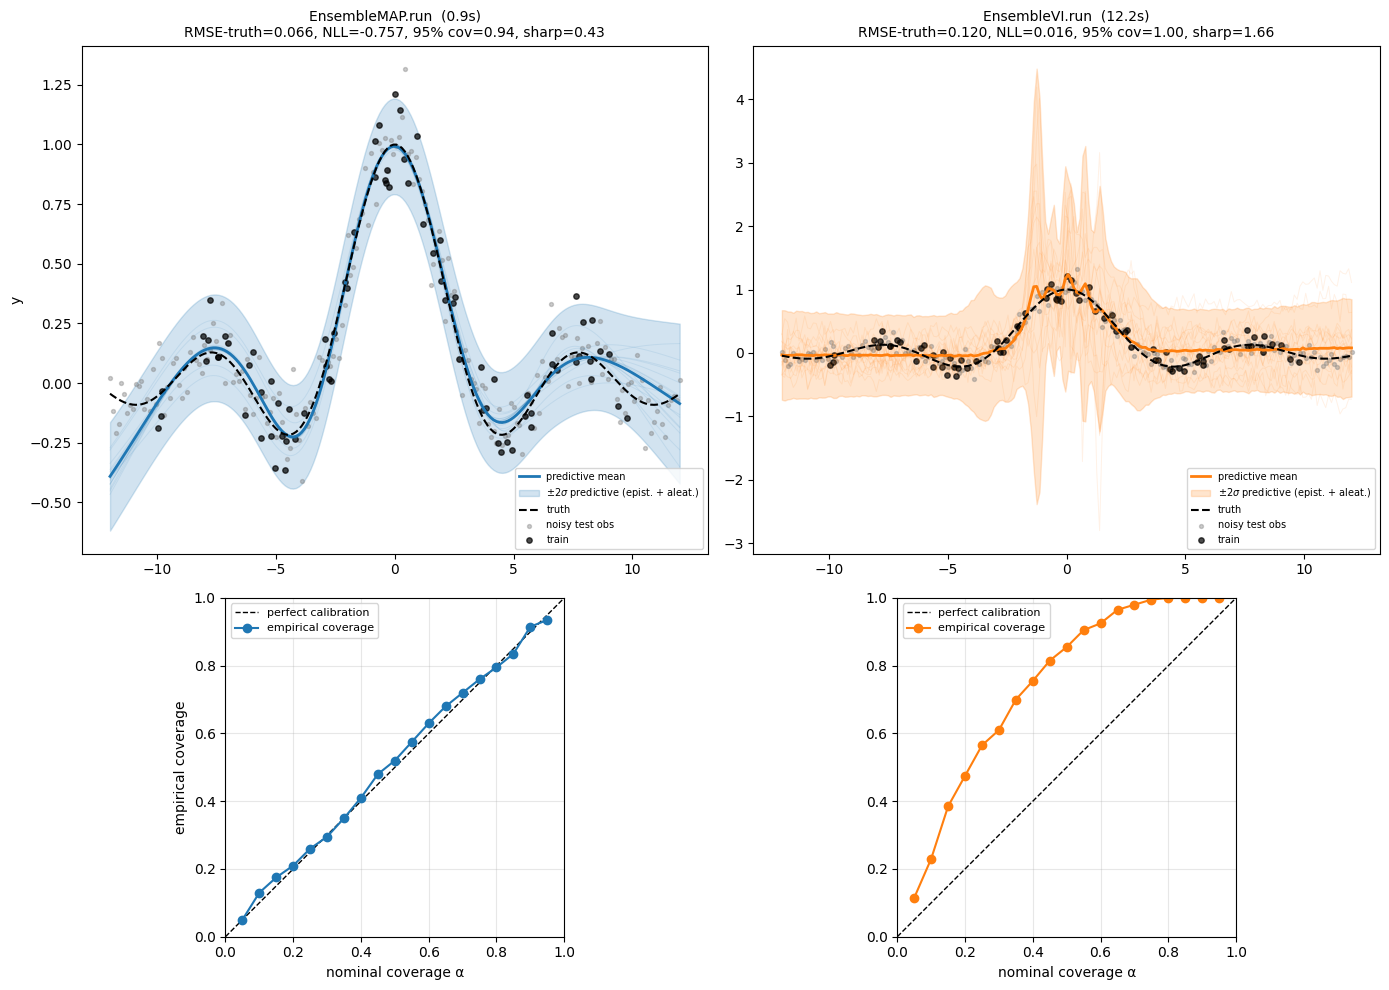

In [11]:
metrics_map = gof_metrics(preds_run, SIGMA, y_truth, y_test_noisy)
metrics_vi = gof_metrics(preds_vi, SIGMA, y_truth, y_test_noisy)

oracle_nll = float(0.5 * jnp.log(2 * jnp.pi * SIGMA**2) + 0.5)
oracle_width = 4 * SIGMA

fig, axes = plt.subplots(
    2, 2, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 2]}, sharex="row"
)
panels = [
    ("EnsembleMAP.run", preds_run, dt_run, metrics_map, "C0"),
    ("EnsembleVI.run", preds_vi, dt_vi, metrics_vi, "C1"),
]

for j, (label, preds, dt, m, color) in enumerate(panels):
    mean, total_std = predictive_band(preds, SIGMA)
    ax_top = axes[0, j]
    # Show a thinned set of member traces.
    member_step = max(1, preds.shape[0] // 16)
    for member in preds[::member_step]:
        ax_top.plot(X_test, member, color=color, alpha=0.10, lw=0.7)
    ax_top.plot(X_test, mean, color=color, lw=2, label="predictive mean")
    ax_top.fill_between(
        X_test,
        mean - 2 * total_std,
        mean + 2 * total_std,
        color=color,
        alpha=0.2,
        label=r"$\pm 2\sigma$ predictive (epist. + aleat.)",
    )
    ax_top.plot(X_test, y_truth, "k--", lw=1.5, label="truth")
    ax_top.scatter(
        X_test, y_test_noisy, s=8, color="grey", alpha=0.4, label="noisy test obs"
    )
    ax_top.scatter(X, y, s=15, color="black", alpha=0.7, label="train")
    ax_top.set_title(
        f"{label}  ({dt:.1f}s)\n"
        f"RMSE-truth={m['rmse_truth']:.3f}, NLL={m['nll']:.3f}, "
        f"95% cov={m['coverage_95']:.2f}, sharp={m['sharpness_95']:.2f}",
        fontsize=10,
    )
    if j == 0:
        ax_top.set_ylabel("y")
    ax_top.legend(loc="lower right", fontsize=7)

    ax_bot = axes[1, j]
    ax_bot.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
    ax_bot.plot(
        m["alphas"], m["coverage_curve"], "o-", color=color, label="empirical coverage"
    )
    ax_bot.set_xlabel("nominal coverage α")
    if j == 0:
        ax_bot.set_ylabel("empirical coverage")
    ax_bot.set_xlim(0, 1)
    ax_bot.set_ylim(0, 1)
    ax_bot.set_aspect("equal")
    ax_bot.grid(alpha=0.3)
    ax_bot.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

### Summary table — full goodness-of-fit comparison

In [12]:
print(f"oracle NLL (perfect f, known σ): {oracle_nll:.3f}")
print(f"oracle 95% interval width (4σ):  {oracle_width:.2f}")
print()
print(
    f"{'Pattern':<40} {'Runtime':>8} {'RMSE-truth':>11} {'RMSE-obs':>9} {'NLL':>8} {'cov95':>7} {'sharp95':>9}"
)
all_rows = [
    ("EnsembleMAP.init+update (jit loop)", preds_iu, dt_iu),
    ("EnsembleMAP.run (lax.scan)", preds_run, dt_run),
    ("ensemble_map sugar", preds_sugar, dt_sugar),
    ("EnsembleVI.run", preds_vi, dt_vi),
]
for label, preds, dt in all_rows:
    m = gof_metrics(preds, SIGMA, y_truth, y_test_noisy)
    print(
        f"{label:<40} {dt:>7.2f}s {m['rmse_truth']:>11.4f} {m['rmse_obs']:>9.4f} "
        f"{m['nll']:>8.3f} {m['coverage_95']:>7.2f} {m['sharpness_95']:>9.3f}"
    )

oracle NLL (perfect f, known σ): -0.884
oracle 95% interval width (4σ):  0.40

Pattern                                   Runtime  RMSE-truth  RMSE-obs      NLL   cov95   sharp95
EnsembleMAP.init+update (jit loop)          2.97s      0.0612    0.1103   -0.779    0.94     0.413
EnsembleMAP.run (lax.scan)                  0.85s      0.0662    0.1138   -0.757    0.94     0.432
ensemble_map sugar                          2.00s      0.0662    0.1138   -0.757    0.94     0.432


EnsembleVI.run                             12.24s      0.1204    0.1482    0.016    1.00     1.658


## Takeaways

- **Three call patterns, one object.** `init`/`update` gives you full Python control; `run` gives you `lax.scan` speed; the bare `ensemble_map` function gives you a one-liner. Pick whichever ergonomics you need — the underlying maths is identical and `init+update` matches `run` to within seed-dependent permutation order.
- **`EnsembleMAP` and `EnsembleVI` share an API.** Same `init` / `update` / `run` triplet, same `EnsembleResult(params, losses)` return type. The only difference is what each member fits.
- **MAP is near-oracle on this problem.** All three MAP variants land at NLL $\approx -0.77$ against an oracle ceiling of $-0.88$, with 94% empirical coverage at the 95% nominal level and sharpness $\approx 0.41$ versus the irreducible $4\sigma = 0.40$. The point-mass mixture is doing essentially everything the data allows, and the predictive variance is dominated by aleatoric noise inside the training range.
- **Mean-field VI is overdispersed here.** With NLL $\approx 0$, 100% empirical coverage, and sharpness $\approx 1.7$ (more than $4\times$ the oracle), the VI ensemble buys coverage by paying *a lot* of sharpness — the bands are so wide they trivially contain every test observation, but the predictive density at any *specific* observation is small. This is the classic mean-field VI pathology: the diagonal-Gaussian factorization can't represent the strong posterior correlations between MLP weights, so the posterior marginals end up much wider than they should be. Either a richer guide (low-rank, IAF, normalizing flow) or `kl_weight < 1` (cold-posterior temper) typically helps.
- **What "good" looks like.** Read the calibration plots, NLL, and sharpness *together*. NLL alone catches both miscalibration and inaccuracy in one number; coverage tells you the direction of the miscalibration; sharpness tells you the price you're paying for that coverage.
- **When to drop down:** if you need anything the runner doesn't expose — custom batching, callbacks, early stopping, a non-standard inference loop — see the [primitives tutorial](./ensemble_primitives_tutorial.ipynb).